# STEP 1: Import and Explore Wine Dataset

### Cell 1: Import Libraries

In [1]:
# Basic libraries for data handling
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset (comes built-in with sklearn)
from sklearn.datasets import load_wine

### Cell 2: Load Dataset

In [4]:
wine=load_wine()

### Cell 3: Convert to DataFrame

In [ ]:
# Convert feature data into DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Add target column
df['target'] = wine.target

# Show first 5 rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Cell 4: Understand Dataset Structure

In [6]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Class labels
print("\nClasses:", wine.target_names)

Shape: (178, 14)

Columns:
 Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

Classes: ['class_0' 'class_1' 'class_2']


### Cell 5: Check Data Types & Missing Values

In [7]:
# Data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

# STEP 2: Visual Exploration

### Cell 6: Class Distribution

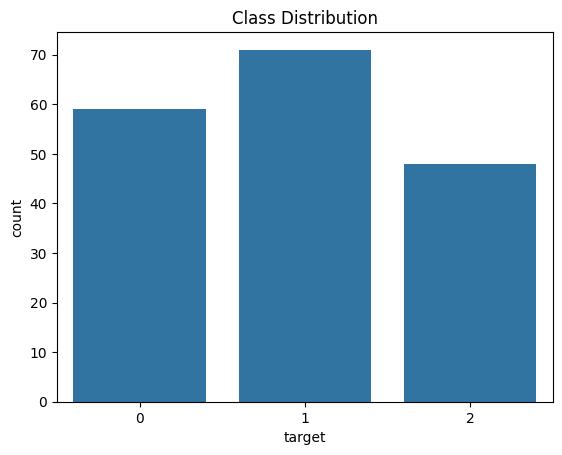

In [8]:
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()

### Cell 7: Correlation Heatmap

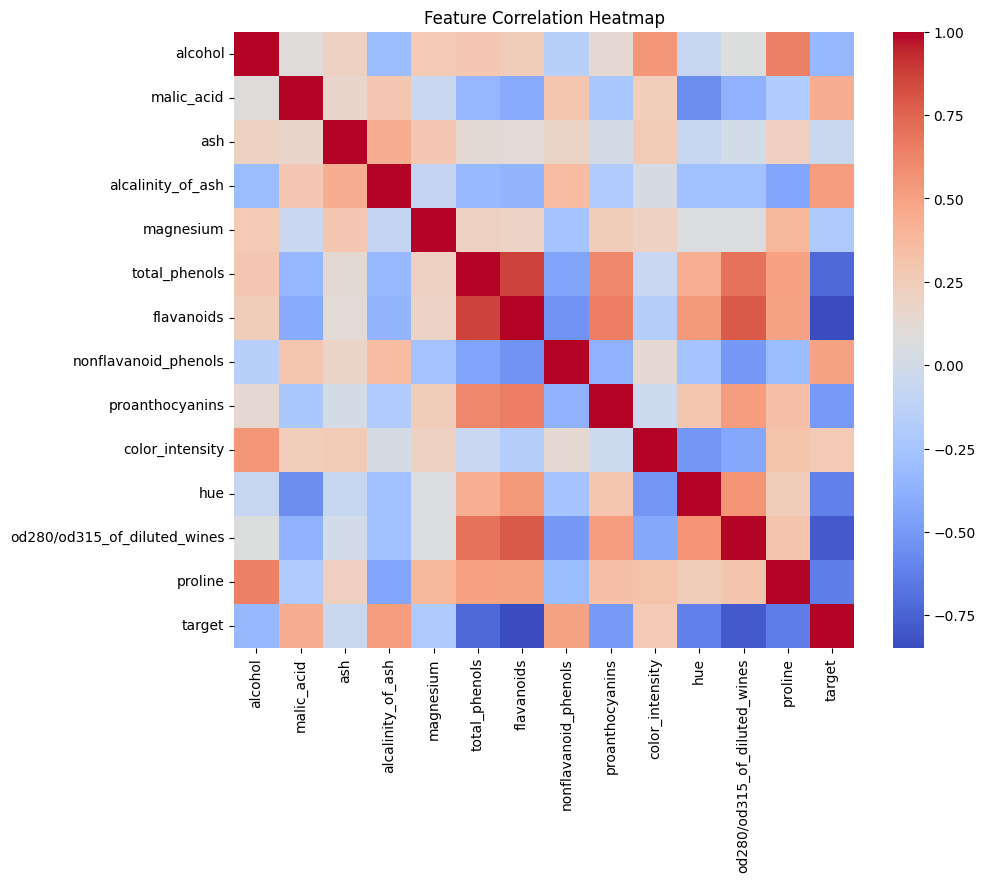

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

### Cell 8: Pairplot (Visual intuition)

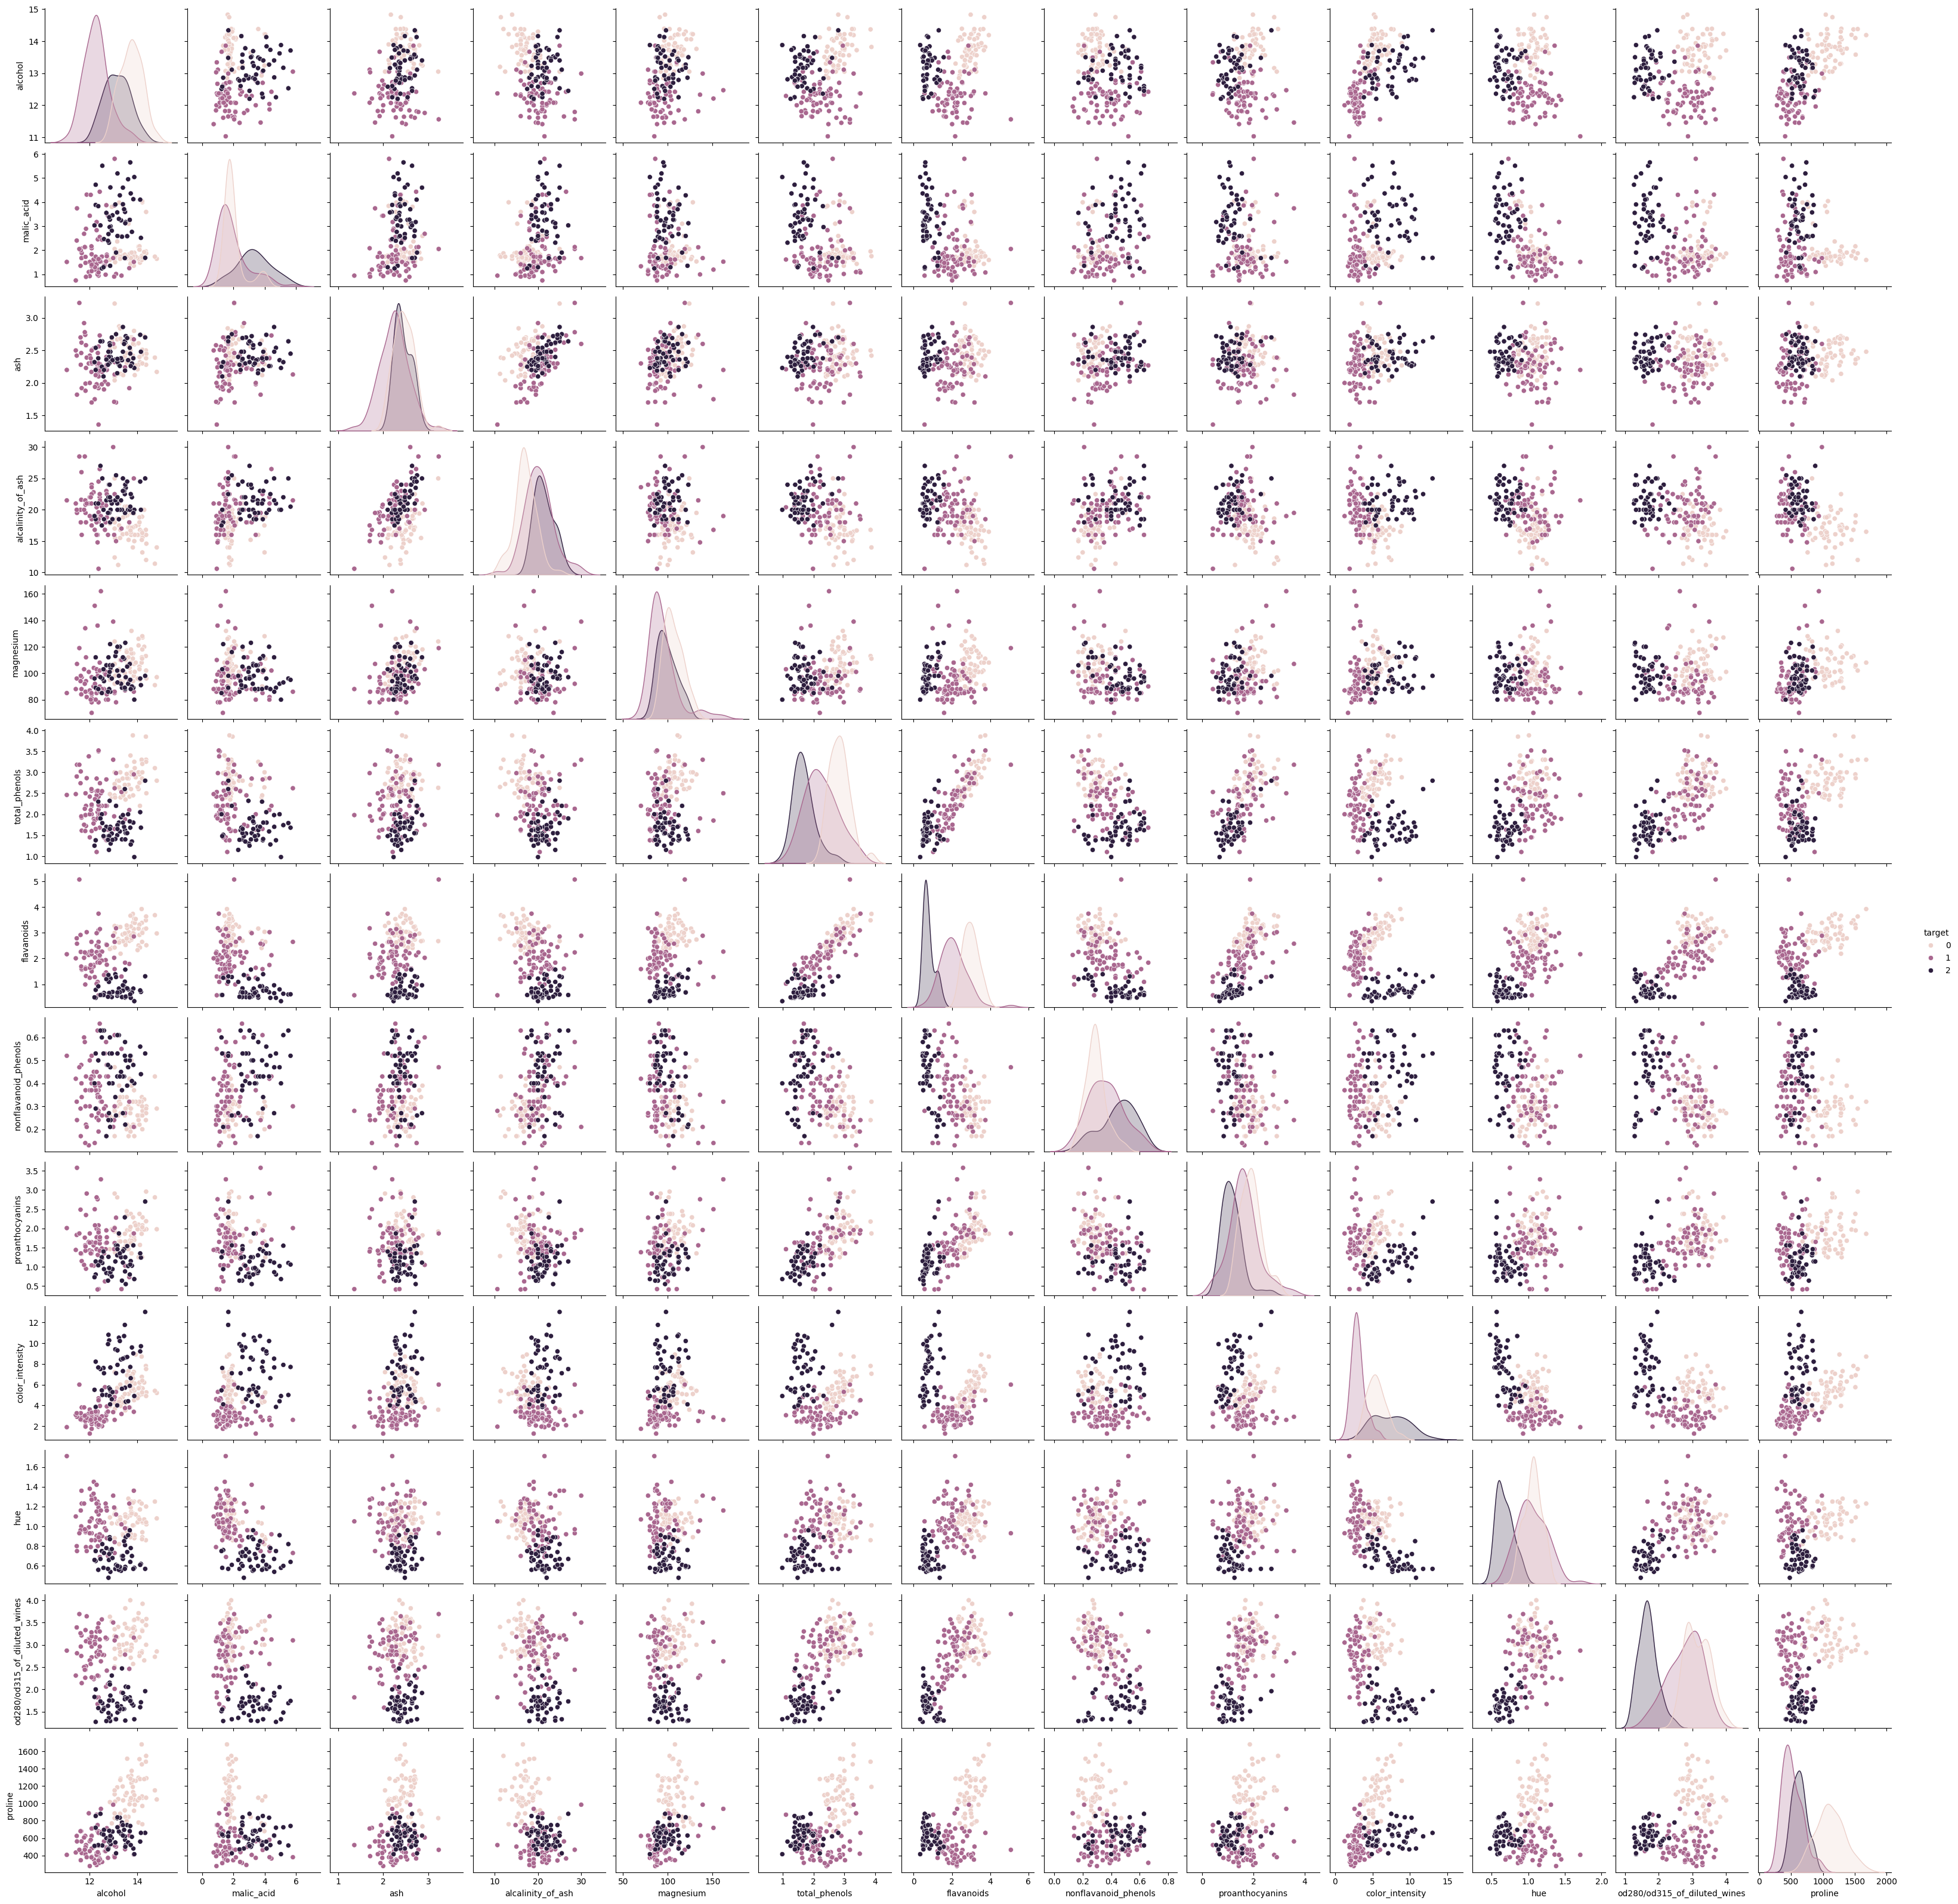

In [10]:
sns.pairplot(df, hue='target')
plt.show()

# STEP 3: Train-Test Split + Feature Scaling

### Cell 9: Split Dataset (70% train, 30% test)

In [11]:
from sklearn.model_selection import train_test_split

# Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (124, 13)
Test shape: (54, 13)


### Cell 10: Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

# STEP 4: Gaussian Naïve Bayes

### Cell 11: Train Model

In [13]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

# Train
nb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


### Cell 12: Predictions

In [14]:
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)

# STEP 5: Evaluation Metrics

### Cell 13: Metrics

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_nb, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_nb, average='weighted'))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


### Cell 14: Confusion Matrix

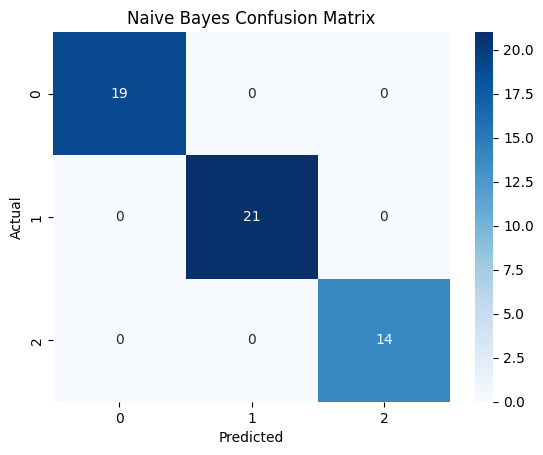

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# STEP 6: ROC Curve + AUC

### Cell 15: ROC Curve

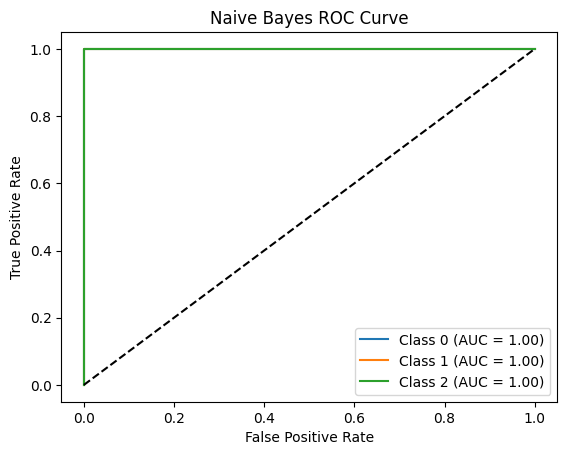

In [17]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure()

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_nb[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes ROC Curve")
plt.legend()
plt.show()

# STEP 7: SVM (Linear Kernel)

### Cell 16: Train Linear SVM

In [18]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', probability=True)

svm_linear.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Cell 17: Predictions

In [19]:
y_pred_svm_lin = svm_linear.predict(X_test_scaled)
y_prob_svm_lin = svm_linear.predict_proba(X_test_scaled)

### Cell 18: Evaluation

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm_lin))
print("Precision:", precision_score(y_test, y_pred_svm_lin, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_svm_lin, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_svm_lin, average='weighted'))

Accuracy: 0.9814814814814815
Precision: 0.982716049382716
Recall: 0.9814814814814815
F1 Score: 0.9815749306918357


### Cell 19: Confusion Matrix

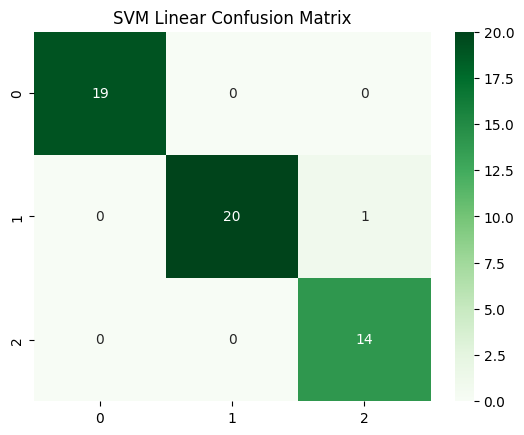

In [21]:
cm = confusion_matrix(y_test, y_pred_svm_lin)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("SVM Linear Confusion Matrix")
plt.show()

# STEP 8: SVM (RBF Kernel)

### Cell 20: Train RBF SVM

In [22]:
svm_rbf = SVC(kernel='rbf', probability=True)

svm_rbf.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Cell 21: Predictions

In [23]:
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)
y_prob_svm_rbf = svm_rbf.predict_proba(X_test_scaled)

### Cell 22: Evaluation

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm_rbf))
print("Precision:", precision_score(y_test, y_pred_svm_rbf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_svm_rbf, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_svm_rbf, average='weighted'))

Accuracy: 0.9814814814814815
Precision: 0.9823232323232324
Recall: 0.9814814814814815
F1 Score: 0.9813538775640411


### Cell 23: Confusion Matrix

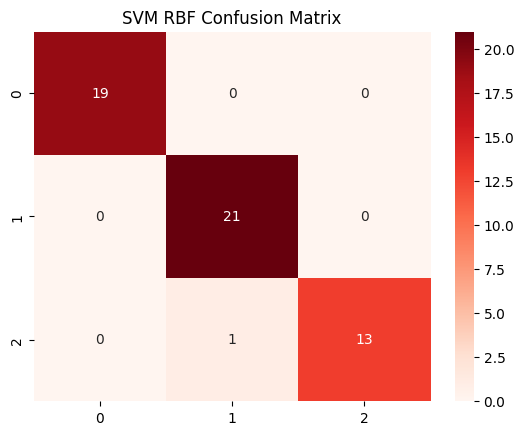

In [25]:
cm = confusion_matrix(y_test, y_pred_svm_rbf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("SVM RBF Confusion Matrix")
plt.show()

# STEP 9: Compare Models

### Cell 24: Comparison Table

In [26]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM Linear", "SVM RBF"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm_lin),
        accuracy_score(y_test, y_pred_svm_rbf)
    ]
})

print(results)

         Model  Accuracy
0  Naive Bayes  1.000000
1   SVM Linear  0.981481
2      SVM RBF  0.981481



### Cell 25: Visualization

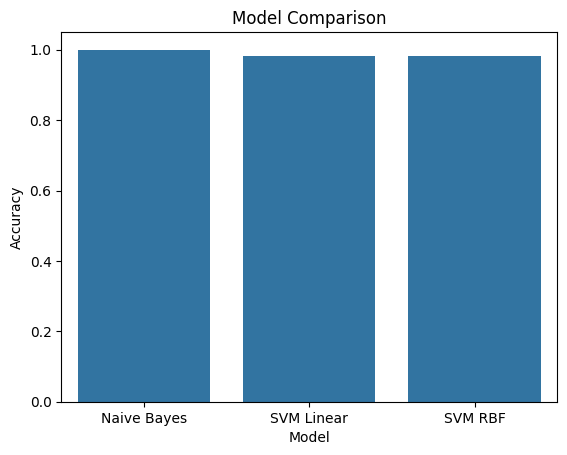

In [27]:
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Comparison")
plt.show()

### Observations

In [28]:
print("\n===== ANALYSIS =====\n")

print("1. Naive Bayes:")
print("- Assumes features are independent.")
print("- Works fast but may not capture complex relationships.\n")

print("2. SVM with Linear Kernel:")
print("- Works well when data is linearly separable.")
print("- Simpler and faster than RBF.\n")

print("3. SVM with RBF Kernel:")
print("- Captures complex (non-linear) patterns.")
print("- Usually gives better accuracy for real-world data.\n")

print("Conclusion:")
print("- If dataset is simple → Linear SVM is sufficient.")
print("- If dataset is complex → RBF kernel performs better.")
print("- Naive Bayes is fastest but less flexible.")


===== ANALYSIS =====

1. Naive Bayes:
- Assumes features are independent.
- Works fast but may not capture complex relationships.

2. SVM with Linear Kernel:
- Works well when data is linearly separable.
- Simpler and faster than RBF.

3. SVM with RBF Kernel:
- Captures complex (non-linear) patterns.
- Usually gives better accuracy for real-world data.

Conclusion:
- If dataset is simple → Linear SVM is sufficient.
- If dataset is complex → RBF kernel performs better.
- Naive Bayes is fastest but less flexible.
